# 06 - Foundation model

**Appliance energy forecasting**

**Inputs**

```text
data/processed/appliance_hourly.csv
outputs/metrics/benchmark_mase_scale.csv
outputs/metrics/benchmark_metrics_rolling.csv
outputs/metrics/sarimax_metrics_rolling.csv
outputs/metrics/feature_metrics_rolling.csv
outputs/forecasts/benchmark_forecasts_rolling.csv
outputs/forecasts/sarimax_forecasts_rolling.csv
```

**Outputs produced**

```text
outputs/forecasts/foundation_forecasts_rolling.csv
outputs/metrics/foundation_metrics_rolling.csv
outputs/metrics/foundation_context_length.csv
outputs/metrics/foundation_run_details.csv
outputs/figures/06_*.png
```

## 1. How the foundation model is being used

The brief asks for this to be stated clearly, so it is set out before any code.

| Question | Answer for this notebook |
|---|---|
| Which model? | **Chronos-Bolt** (`amazon/chronos-bolt-base`), a pretrained encoder-decoder forecaster from Amazon Science |
| Zero-shot or fine-tuned? | **Zero-shot.** No gradient step is taken on this dataset; the weights are exactly as published |
| What does it see? | Only the past values of `Appliances` up to the forecast origin - the *context* |
| Does it use covariates? | **No.** Chronos is a univariate model. Indoor sensors, weather and even the calendar are unavailable to it |
| Does it know the timestamps? | **No.** It receives an ordered sequence of numbers with no dates attached. Any daily periodicity must be inferred from the values themselves |
| Output type | Quantiles of the predictive distribution, which give both a point forecast (median) and prediction intervals directly |

The covariate restriction cuts both ways, and the report should say so. It is a handicap
relative to SARIMAX, which received weather and calendar terms. But notebooks 04 and 05 both
found covariates to be worthless or harmful here, so in this particular problem the handicap
may cost nothing - and the model gains robustness by not depending on a weather feed.

The point worth emphasising is the more surprising one: the model has no calendar. If it
reproduces the daily cycle, it has inferred a period of 24 from the numeric pattern alone.

## 2. Setup

In [1]:
%pip install chronos-forecasting

Note: you may need to restart the kernel to use updated packages.


In [2]:

# 1. Imports

import warnings
warnings.filterwarnings("ignore")

import inspect
import time

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 130)

plt.rcParams["figure.figsize"] = (13, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [3]:

# 2. Configuration

def find_project_root(markers=("data/raw", "data/processed", "notebooks"), start=None):
    """
    Locate the project root by walking up from the working directory.

    The root is the first ancestor containing any of `markers`, so this works on
    a fresh setup (before data/processed exists) as well as later, and does not
    depend on the notebook folder having a particular name.
    """

    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if any((candidate / m).exists() for m in markers):
            return candidate

    raise FileNotFoundError(
        f"No project root found from {start} upwards.\n"
        f"Looked for: {markers}\n"
        "Expected layout:  <project>/notebooks/*.ipynb  and  <project>/data/raw/"
    )


PROJECT_ROOT = find_project_root()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

FORECAST_DIR = OUTPUT_DIR / "forecasts"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURE_DIR = OUTPUT_DIR / "figures"

for path in [FORECAST_DIR, METRICS_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 0
rng = np.random.default_rng(RANDOM_STATE)

TARGET = "Appliances"

HORIZON = 24
TEST_STEPS = 14 * 24
N_WINDOWS = TEST_STEPS // HORIZON

# Foundation model settings
MODEL_NAME = "amazon/chronos-bolt-base"
CONTEXT_LENGTH = 1024              # hours of history shown to the model
# Chronos-Bolt is trained on the deciles 0.1 to 0.9 only. Requesting a level
# outside that range returns the nearest trained quantile, which would silently
# relabel the 80% interval as a 95% one, so only trained levels are requested.
QUANTILE_LEVELS = [0.1, 0.5, 0.9]


def save_fig(fig, name, figure_dir=FIGURE_DIR):
    """Save a figure to outputs/figures and report the path."""

    path = figure_dir / name

    fig.savefig(path, dpi=200, bbox_inches="tight")

    print("Saved figure:", path.relative_to(PROJECT_ROOT))

    return path


print("Project root:", PROJECT_ROOT)

Project root: C:\Users\cjfin\Desktop\assignment 2


In [4]:

# 3. Load data and previous results

data = pd.read_csv(
    PROCESSED_DIR / "appliance_hourly.csv", index_col=0, parse_dates=True
).asfreq("h")

y = data[TARGET]

train = y.iloc[:-TEST_STEPS]
test = y.iloc[-TEST_STEPS:]

SCALE = float(
    pd.read_csv(METRICS_DIR / "benchmark_mase_scale.csv", index_col=0).loc["mase_scale", "value"]
)

benchmark_metrics = pd.read_csv(METRICS_DIR / "benchmark_metrics_rolling.csv")
sarimax_metrics = pd.read_csv(METRICS_DIR / "sarimax_metrics_rolling.csv")
feature_metrics = pd.read_csv(METRICS_DIR / "feature_metrics_rolling.csv")

BEST_BENCHMARK = benchmark_metrics.iloc[0]["model"]
BEST_BENCHMARK_MASE = float(benchmark_metrics.iloc[0]["MASE"])

print("Train:", len(train), "| Test:", len(test))
print(f"Bar to clear: {BEST_BENCHMARK} at MASE {BEST_BENCHMARK_MASE:.3f}")


def evaluate_forecast(name, y_true, y_pred, scale=None):
    """MAE, RMSE, MASE and Bias - identical to notebooks 03 to 05."""

    scale = SCALE if scale is None else scale

    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).reindex(y_true.index).astype(float)

    valid = y_true.notna() & y_pred.notna()

    errors = y_pred[valid] - y_true[valid]

    return {
        "model": name,
        "n": int(valid.sum()),
        "MAE": float(np.mean(np.abs(errors))),
        "RMSE": float(np.sqrt(np.mean(errors ** 2))),
        "MASE": float(np.mean(np.abs(errors)) / scale),
        "Bias": float(np.mean(errors)),
    }

Train: 2953 | Test: 336
Bar to clear: seasonal_naive_weekly at MASE 0.804


## 3. Loading the model

Chronos requires `torch` and the `chronos-forecasting` package, and downloads its weights
from Hugging Face on first use:

```bash
pip install chronos-forecasting
```

Roughly 800 MB is downloaded for `chronos-bolt-base` and cached in `~/.cache/huggingface`,
so the first run is slower than later ones. CPU inference is fast enough for this dataset -
14 windows of 24 steps takes seconds - so a GPU is convenient rather than necessary.

If the import or the download fails, the cell below raises immediately rather than
continuing with a substitute forecast. That is deliberate: a silent fallback could put
numbers into the comparison table that did not come from a foundation model.

In [5]:

# 4. Load the foundation model

import torch

from chronos import BaseChronosPipeline

started = time.time()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = BaseChronosPipeline.from_pretrained(
    MODEL_NAME,
    device_map=DEVICE,
    torch_dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32,
)

MODEL_LABEL = "chronos_bolt_base"

print(f"Loaded {MODEL_NAME} in {time.time() - started:.0f}s")
print("Device:", DEVICE)
print("Model label for this run:", MODEL_LABEL)

Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

Loaded amazon/chronos-bolt-base in 2s
Device: cpu
Model label for this run: chronos_bolt_base


## 4. The forecasting interface

The model is wrapped in one function: given a list of context windows, it returns a point
forecast and quantiles for the next 24 hours of each.

Chronos is called in **batch** - all 14 context windows are passed at once, which is far
faster than looping, and each window's forecast still depends only on its own context. The
shape of the returned array is asserted, so a change in the library's output layout is
caught at the point of failure rather than flowing silently into the metrics.

In [6]:

# 5. Forecast function


def foundation_forecast(contexts, prediction_length=HORIZON, quantile_levels=QUANTILE_LEVELS):
    """
    Forecast each context window with the pretrained model.

    contexts    list of 1-D arrays, each the history available at one origin
    returns     (point, quantiles)
                point     array [n_windows, prediction_length]
                quantiles array [n_windows, prediction_length, n_quantiles]

    All windows are passed to Chronos in a single batch, which is far faster than
    looping. Each window's forecast still depends only on its own context.
    """

    tensors = [torch.tensor(np.asarray(c, dtype=np.float32)) for c in contexts]

    # chronos-forecasting renamed the input argument from `context` to `inputs`
    # in version 2.x, so the keyword is resolved at call time.
    parameters = inspect.signature(pipeline.predict_quantiles).parameters
    input_keyword = "inputs" if "inputs" in parameters else "context"

    output = pipeline.predict_quantiles(**{
        input_keyword: tensors,
        "prediction_length": prediction_length,
        "quantile_levels": quantile_levels,
    })

    # Some versions return (quantiles, mean); others return quantiles only.
    quantiles = output[0] if isinstance(output, tuple) else output

    if hasattr(quantiles, "detach"):
        quantiles = quantiles.detach().float().numpy()

    quantiles = np.asarray(quantiles)

    assert quantiles.shape == (len(contexts), prediction_length, len(quantile_levels)), (
        f"Unexpected quantile shape {quantiles.shape}; expected "
        f"{(len(contexts), prediction_length, len(quantile_levels))}"
    )

    median_position = quantile_levels.index(0.5)

    return quantiles[:, :, median_position], quantiles


def build_contexts(y_series, test_index, context_length=CONTEXT_LENGTH, horizon=HORIZON):
    """
    One context window per forecast origin.

    The context for window w ends at the last observation before that window, so
    no target value from inside a window can reach its own forecast.
    """

    split = y_series.index.get_loc(test_index[0])

    contexts = []

    for window in range(len(test_index) // horizon):
        end = split + window * horizon

        start = max(0, end - context_length)

        contexts.append(y_series.iloc[start:end].values)

        # Leakage guard.
        assert y_series.index[end - 1] < test_index[window * horizon]

    return contexts


contexts = build_contexts(y, test.index)

print("Context windows:", len(contexts))
print("Context lengths:", sorted({len(c) for c in contexts}))
print("First context ends:", y.index[y.index.get_loc(test.index[0]) - 1])
print("First window starts:", test.index[0])

Context windows: 14
Context lengths: [1024]
First context ends: 2016-05-13 17:00:00
First window starts: 2016-05-13 18:00:00


## 5. Rolling-origin forecasts

In [7]:

# 6. Forecast all 14 windows

started = time.time()

point_forecasts, quantile_forecasts = foundation_forecast(contexts)

elapsed = time.time() - started

foundation_point = pd.Series(point_forecasts.reshape(-1), index=test.index)

quantile_frame = pd.DataFrame(
    quantile_forecasts.reshape(-1, len(QUANTILE_LEVELS)),
    index=test.index,
    columns=[f"q{int(level * 1000):04d}" for level in QUANTILE_LEVELS],
)

# Appliance energy use cannot be negative.
foundation_point = foundation_point.clip(lower=0)
quantile_frame = quantile_frame.clip(lower=0)

print(f"Forecast {len(contexts)} windows in {elapsed:.1f}s")
print()
print(evaluate_forecast(MODEL_LABEL, test, foundation_point))

Forecast 14 windows in 3.4s

{'model': 'chronos_bolt_base', 'n': 336, 'MAE': 33.629169910673106, 'RMSE': 66.00770803909009, 'MASE': 0.6302443475309196, 'Bias': -15.595866612025667}


Saved figure: outputs\figures\06_foundation_profile_and_window.png


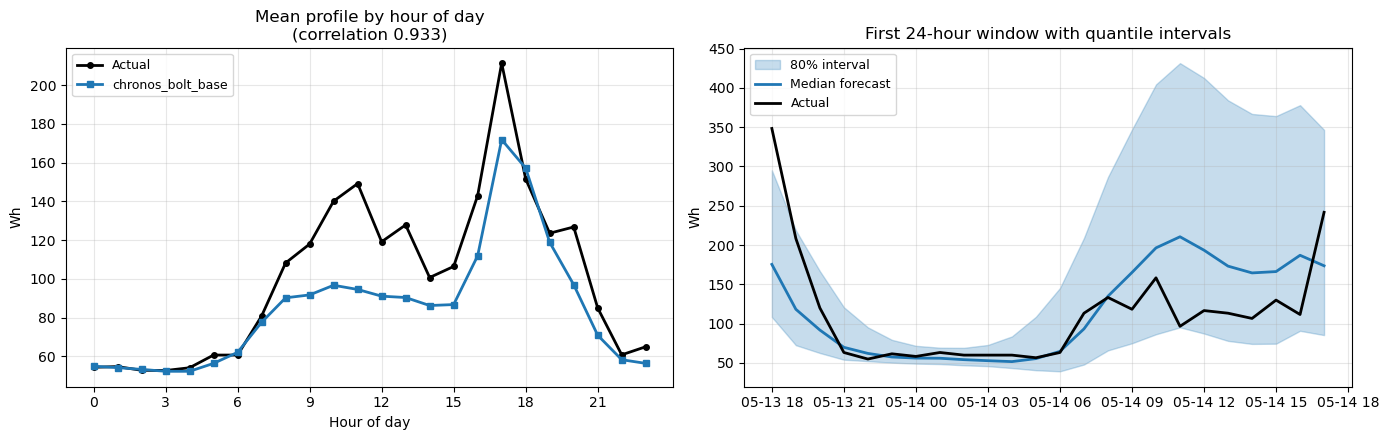

Correlation between forecast and actual hourly profile: 0.933


In [8]:

# 7. Does the model reproduce the daily cycle without a calendar?

# The model never receives timestamps, so any daily structure in its forecasts
# was inferred from the numeric pattern of the context alone.
forecast_profile = foundation_point.groupby(foundation_point.index.hour).mean()
actual_profile = test.groupby(test.index.hour).mean()

profile_correlation = float(forecast_profile.corr(actual_profile))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(actual_profile.index, actual_profile.values, color="black",
             linewidth=2, marker="o", markersize=4, label="Actual")
axes[0].plot(forecast_profile.index, forecast_profile.values, color="tab:blue",
             linewidth=2, marker="s", markersize=4, label=MODEL_LABEL)
axes[0].set_title(f"Mean profile by hour of day\n(correlation {profile_correlation:.3f})")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Wh")
axes[0].set_xticks(range(0, 24, 3))
axes[0].legend(fontsize=9)

first_window = test.index[:HORIZON]

axes[1].fill_between(first_window,
                     quantile_frame["q0100"].iloc[:HORIZON],
                     quantile_frame["q0900"].iloc[:HORIZON],
                     color="tab:blue", alpha=0.25, label="80% interval")
axes[1].plot(first_window, foundation_point.iloc[:HORIZON], color="tab:blue",
             linewidth=2, label="Median forecast")
axes[1].plot(first_window, test.iloc[:HORIZON], color="black",
             linewidth=2, label="Actual")
axes[1].set_title("First 24-hour window with quantile intervals")
axes[1].set_ylabel("Wh")
axes[1].legend(fontsize=9)

fig.tight_layout()
save_fig(fig, "06_foundation_profile_and_window.png")

plt.show()

print("Correlation between forecast and actual hourly profile:", round(profile_correlation, 3))

This figure answers a question none of the other models pose. Chronos receives an ordered
list of numbers with no dates. If the forecast profile tracks the actual one, the model has
inferred a 24-period cycle purely from the numeric pattern - and that inference, made
without any calendar feature, is what the model is bringing in place of local training.

## 6. How much context does it need?

Context length is the main free parameter in zero-shot use. Too short and the model cannot
see the weekly pattern; too long and older, seasonally different behaviour may dilute the
recent regime. Chronos-Bolt accepts up to 2,048 steps.

This sweep uses the training history only in the sense that matters: each context still ends
at its own forecast origin. It is a legitimate sensitivity analysis, but note that choosing
the context length by test-period MASE would be selecting on the test set. The value fixed
in section 2 stands regardless of what this shows.

Accuracy by context length:

 context_hours  context_days    MAE  MASE  seconds  selected
            72           3.0 37.967 0.712    0.289     False
           168           7.0 35.905 0.673    0.389     False
           336          14.0 35.052 0.657    0.780     False
           512          21.3 33.580 0.629    1.220     False
          1024          42.7 33.629 0.630    1.936      True
          2048          85.3 33.684 0.631    3.382     False
Saved figure: outputs\figures\06_context_length.png


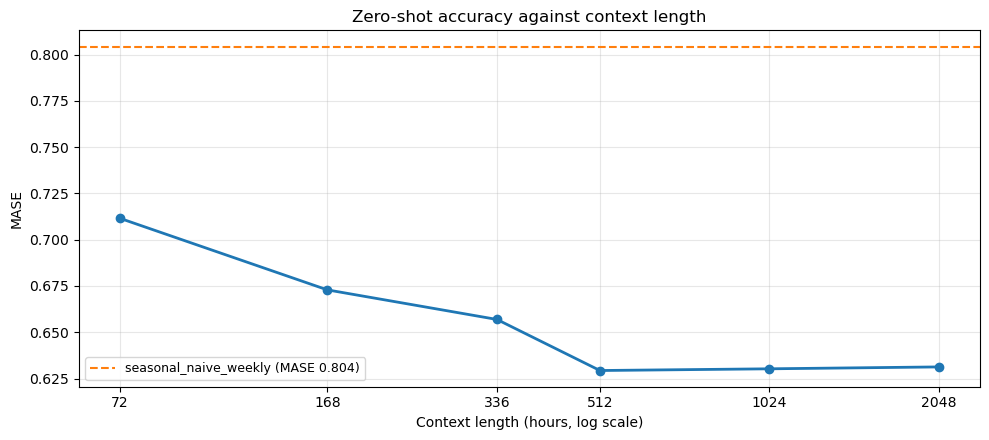

In [9]:

# 8. Context-length sweep

CONTEXT_CANDIDATES = [72, 168, 336, 512, 1024, 2048]

context_rows = []

for candidate in CONTEXT_CANDIDATES:
    candidate_contexts = build_contexts(y, test.index, context_length=candidate)

    started = time.time()

    candidate_point, _ = foundation_forecast(candidate_contexts)

    candidate_series = pd.Series(candidate_point.reshape(-1), index=test.index).clip(lower=0)

    metrics = evaluate_forecast(f"context_{candidate}", test, candidate_series)

    context_rows.append({
        "context_hours": candidate,
        "context_days": round(candidate / 24, 1),
        "MAE": metrics["MAE"],
        "MASE": metrics["MASE"],
        "seconds": time.time() - started,
        "selected": candidate == CONTEXT_LENGTH,
    })

context_results = pd.DataFrame(context_rows)

context_results.to_csv(METRICS_DIR / "foundation_context_length.csv", index=False)

print("Accuracy by context length:\n")
print(context_results.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(context_results["context_hours"], context_results["MASE"],
        marker="o", linewidth=2, color="tab:blue")
ax.axhline(BEST_BENCHMARK_MASE, color="tab:orange", linestyle="--",
           label=f"{BEST_BENCHMARK} (MASE {BEST_BENCHMARK_MASE:.3f})")
ax.set_xscale("log", base=2)
ax.set_xticks(CONTEXT_CANDIDATES, [str(c) for c in CONTEXT_CANDIDATES])
ax.set_xlabel("Context length (hours, log scale)")
ax.set_ylabel("MASE")
ax.set_title("Zero-shot accuracy against context length")
ax.legend(fontsize=9)

fig.tight_layout()
save_fig(fig, "06_context_length.png")

plt.show()

## 7. Results

In [10]:

# 9. Comparison with every model so far

foundation_metrics = pd.DataFrame([evaluate_forecast(MODEL_LABEL, test, foundation_point)])

combined = (
    pd.concat([foundation_metrics, feature_metrics, sarimax_metrics, benchmark_metrics],
              ignore_index=True)
    .sort_values("MASE")
    .reset_index(drop=True)
)

print("Rolling-origin performance, every model in the project:\n")
print(combined.round(3).to_string(index=False))

Rolling-origin performance, every model in the project:

                   model   n     MAE    RMSE  MASE    Bias
       chronos_bolt_base 336  33.629  66.008 0.630 -15.596
      sarima_target_only 336  36.785  64.205 0.689  -4.652
       feature_recursive 336  37.484  61.082 0.702   0.208
        sarimax_calendar 336  37.899  64.256 0.710  -4.993
sarimax_calendar_weather 336  38.372  64.742 0.719  -3.206
   feature_restricted_24 336  38.558  65.756 0.723  -4.369
          feature_direct 336  38.585  65.272 0.723  -3.947
      feature_cov_lagged 336  40.121  64.932 0.752  -2.019
   seasonal_naive_weekly 336  42.922  79.668 0.804 -12.624
    feature_cov_realised 336  45.977  68.207 0.862   9.265
    seasonal_naive_daily 336  48.393  85.790 0.907   1.667
                    mean 336  50.010  73.986 0.937  -3.061
                   naive 336 143.383 170.623 2.687 114.673
                   drift 336 143.942 171.260 2.698 115.314


In [11]:

# 10. Is the difference from the benchmark meaningful?

benchmark_rolling = pd.read_csv(
    FORECAST_DIR / "benchmark_forecasts_rolling.csv", index_col=0, parse_dates=True
)

sarimax_rolling = pd.read_csv(
    FORECAST_DIR / "sarimax_forecasts_rolling.csv", index_col=0, parse_dates=True
)


def bootstrap_mae_difference(errors_a, errors_b, n_boot=2000, rng=rng):
    """Percentile bootstrap CI for a difference in MAE, resampling 24-hour blocks."""

    a = np.abs(np.asarray(errors_a)).reshape(-1, HORIZON)
    b = np.abs(np.asarray(errors_b)).reshape(-1, HORIZON)

    observed = a.mean() - b.mean()

    draws = np.empty(n_boot)

    for i in range(n_boot):
        idx = rng.integers(0, a.shape[0], a.shape[0])
        draws[i] = a[idx].mean() - b[idx].mean()

    return observed, *np.percentile(draws, [2.5, 97.5])


foundation_errors = (foundation_point - test).values

rows = []

for label, reference in [
    (BEST_BENCHMARK, benchmark_rolling[BEST_BENCHMARK] - benchmark_rolling["actual"]),
    ("sarima_target_only", sarimax_rolling["sarima_target_only"] - sarimax_rolling["actual"]),
]:
    observed, lower, upper = bootstrap_mae_difference(foundation_errors, reference.values)

    rows.append({
        "compared_with": label,
        "MAE_difference": observed,
        "ci_lower": lower,
        "ci_upper": upper,
        "verdict": ("foundation clearly worse" if lower > 0
                    else "foundation clearly better" if upper < 0
                    else "indistinguishable"),
    })

print(f"MAE difference: {MODEL_LABEL} minus the comparison model.")
print("Negative means the foundation model is better.\n")
print(pd.DataFrame(rows).round(2).to_string(index=False))

MAE difference: chronos_bolt_base minus the comparison model.
Negative means the foundation model is better.

        compared_with  MAE_difference  ci_lower  ci_upper                   verdict
seasonal_naive_weekly           -9.29    -18.57     -1.54 foundation clearly better
   sarima_target_only           -3.16     -9.43      3.43         indistinguishable


Saved figure: outputs\figures\06_foundation_error_analysis.png


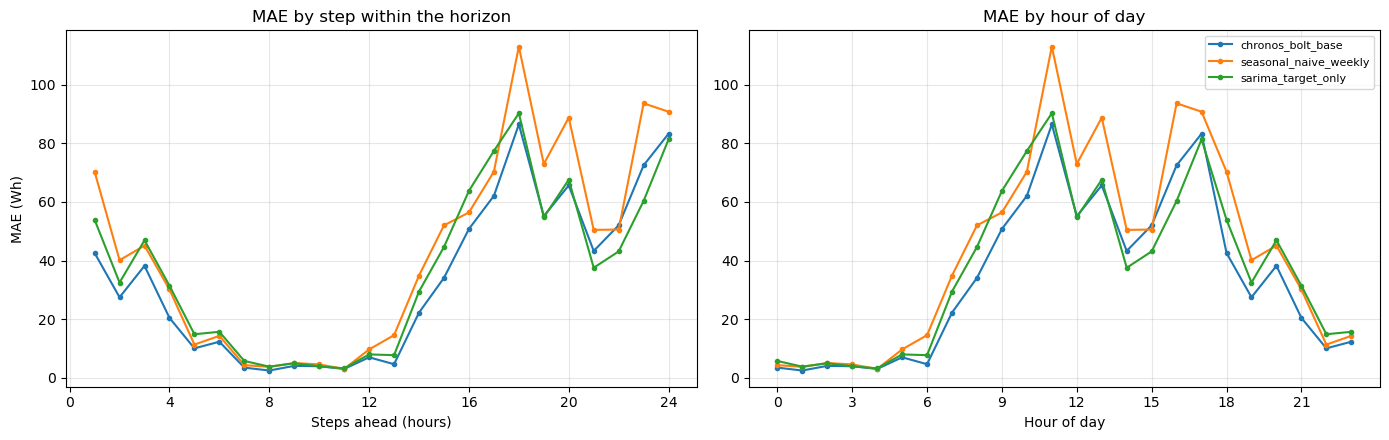

      chronos_bolt_base  seasonal_naive_weekly  sarima_target_only
step                                                              
1                  42.6                   70.4                53.9
6                  12.3                   14.3                15.7
12                  7.0                    9.6                 7.9
18                 86.5                  113.1                90.3
24                 83.3                   90.8                81.4


In [12]:

# 11. Where does it do well or badly?

step_index = pd.Series(
    np.tile(np.arange(1, HORIZON + 1), N_WINDOWS), index=test.index, name="step"
)

comparison = pd.DataFrame({
    MODEL_LABEL: (foundation_point - test).abs(),
    BEST_BENCHMARK: (benchmark_rolling[BEST_BENCHMARK] - test).abs(),
    "sarima_target_only": (sarimax_rolling["sarima_target_only"] - test).abs(),
})

by_step = comparison.groupby(step_index).mean()
by_hour = comparison.groupby(comparison.index.hour).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for column in comparison.columns:
    axes[0].plot(by_step.index, by_step[column], marker="o", markersize=3, label=column)
    axes[1].plot(by_hour.index, by_hour[column], marker="o", markersize=3, label=column)

axes[0].set_title("MAE by step within the horizon")
axes[0].set_xlabel("Steps ahead (hours)")
axes[0].set_ylabel("MAE (Wh)")
axes[0].set_xticks(range(0, 25, 4))

axes[1].set_title("MAE by hour of day")
axes[1].set_xlabel("Hour of day")
axes[1].set_xticks(range(0, 24, 3))
axes[1].legend(fontsize=8)

fig.tight_layout()
save_fig(fig, "06_foundation_error_analysis.png")

plt.show()

print(by_step.loc[[1, 6, 12, 18, 24]].round(1).to_string())

Saved figure: outputs\figures\06_foundation_forecasts.png


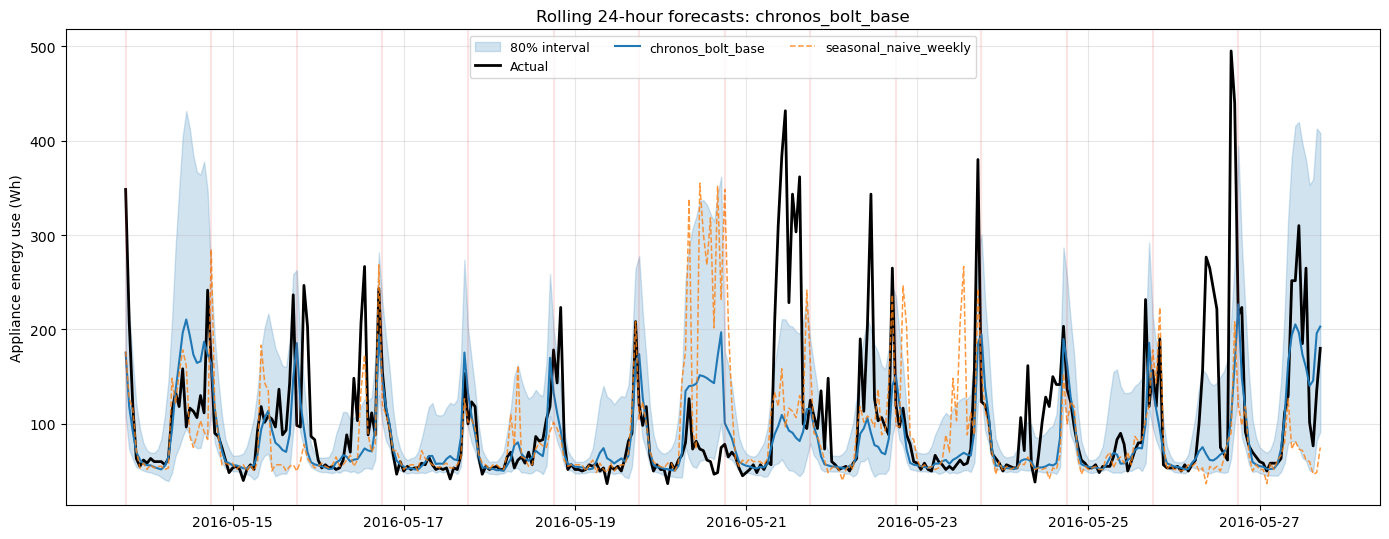

In [13]:

# 12. Forecasts across the test period

fig, ax = plt.subplots(figsize=(14, 5.5))

ax.fill_between(test.index, quantile_frame["q0100"], quantile_frame["q0900"],
                color="tab:blue", alpha=0.20, label="80% interval")

ax.plot(test.index, test.values, color="black", linewidth=2, label="Actual")
ax.plot(foundation_point.index, foundation_point.values, color="tab:blue",
        linewidth=1.5, label=MODEL_LABEL)
ax.plot(benchmark_rolling.index, benchmark_rolling[BEST_BENCHMARK],
        color="tab:orange", linewidth=1.1, linestyle="--", alpha=0.8, label=BEST_BENCHMARK)

for window in range(N_WINDOWS):
    ax.axvline(test.index[window * HORIZON], color="tab:red", alpha=0.12)

ax.set_title(f"Rolling 24-hour forecasts: {MODEL_LABEL}")
ax.set_ylabel("Appliance energy use (Wh)")
ax.legend(ncol=3, fontsize=9)

fig.tight_layout()
save_fig(fig, "06_foundation_forecasts.png")

plt.show()

## 8. Are the quantiles calibrated?

This is where a foundation model has a structural advantage worth testing. SARIMAX intervals
are Gaussian by assumption, and notebook 04 showed its breaches falling almost entirely above
the upper bound - a symmetric interval is the wrong shape for a right-skewed series. Chronos
predicts quantiles directly, so its intervals can be asymmetric without any distributional
assumption.

**One constraint applies.** Chronos-Bolt is trained on the deciles 0.1 to 0.9 only.
Requesting a level outside that range returns the nearest trained quantile, so a nominal 95%
interval would in fact be the 80% one relabelled. All three methods are therefore compared at
**80%**, which is like-for-like and still answers the question. The inability to produce an
extreme quantile without fine-tuning or a sampling-based variant is itself a limitation worth
reporting.

In [14]:

# 13. Interval coverage against notebooks 03 and 04

# All three methods are compared at the same nominal level. Chronos-Bolt is not
# trained beyond the 0.1 and 0.9 quantiles, so it cannot produce a genuine 95%
# interval; comparing a clamped one against the Gaussian and empirical 95%
# intervals would not be like-for-like.

foundation_intervals = pd.DataFrame({
    "actual": test,
    "lower_80": quantile_frame["q0100"],
    "upper_80": quantile_frame["q0900"],
})


def interval_summary(frame, actual_col="actual"):
    """Coverage, mean width, and the direction of interval failures at 80%."""

    actual = frame[actual_col]

    inside = (actual >= frame["lower_80"]) & (actual <= frame["upper_80"])

    return pd.Series({
        "coverage_80": float(inside.mean()),
        "mean_width_80": float((frame["upper_80"] - frame["lower_80"]).mean()),
        "breaches_above": int((actual > frame["upper_80"]).sum()),
        "breaches_below": int((actual < frame["lower_80"]).sum()),
    })


benchmark_intervals = pd.read_csv(
    FORECAST_DIR / "benchmark_prediction_intervals.csv", index_col=0, parse_dates=True
)

interval_comparison = pd.DataFrame({
    f"{MODEL_LABEL}_quantiles": interval_summary(foundation_intervals),
    "sarima_gaussian": interval_summary(sarimax_rolling),
    "benchmark_empirical": interval_summary(benchmark_intervals),
}).T

print("Nominal coverage is 0.80 for all three methods.\n")
print(interval_comparison.round(3).to_string())

print("\nA balanced breach count means the interval has the right shape;")
print("breaches concentrated on one side mean it is the wrong shape, however wide.")

Nominal coverage is 0.80 for all three methods.

                             coverage_80  mean_width_80  breaches_above  breaches_below
chronos_bolt_base_quantiles        0.824         91.020            38.0            21.0
sarima_gaussian                    0.902        168.111            28.0             5.0
benchmark_empirical                0.851        154.356            27.0            23.0

A balanced breach count means the interval has the right shape;
breaches concentrated on one side mean it is the wrong shape, however wide.


Three things to look for when reading this table:

* **Coverage near nominal** means the width is honest.
* **Narrower intervals at the same coverage** means genuinely sharper uncertainty
  quantification, which is the real prize - a battery controller can act on a tight,
  well-calibrated interval, and cannot act on a wide one.
* **Balanced breaches** - roughly equal numbers above and below - means the interval has the
  right *shape*. SARIMAX failed this test badly in notebook 04 with every breach above the
  upper bound. A quantile forecaster should do better, and if it does not, that is worth
  reporting too.

## 9. The leakage question unique to this model class

Every other model in this project was fitted on the training split, so leakage was a
question about *this* dataset. A foundation model raises a different one: **was this dataset
part of the model's pretraining corpus?**

Chronos was pretrained on a large collection of public time-series datasets, plus synthetic
data. The Appliances Energy Prediction dataset is a well-known public benchmark hosted on
the UCI repository. If it appears in the pretraining mix, then "zero-shot" is not the same
as "has never seen this series", and any strong result should be discounted accordingly.

Points the report should make:

1. **State the risk explicitly.** Naming it demonstrates understanding of what zero-shot
   evaluation means, and costs nothing.
2. **Check the published corpus.** The Chronos paper lists its training datasets and its
   held-out evaluation sets. Cite what it says about this dataset rather than speculating.
3. **Note the direction of the bias.** Contamination would inflate the foundation model's
   apparent performance, so it is a threat to a *positive* result. If the model does not beat
   the benchmark, contamination is not an alternative explanation for the finding.
4. **Note what is not at risk.** Pretraining predates this project entirely, so contamination
   cannot have been influenced by any choice made here. It is a property of the model, not a
   flaw in the experimental design.

There is no way to resolve this from inside the notebook, which is exactly why it belongs in
the limitations section rather than being quietly ignored.

## 10. Save outputs

In [15]:

# 14. Save forecasts, metrics and provenance

foundation_forecasts = pd.DataFrame({
    "actual": test,
    MODEL_LABEL: foundation_point,
    "window": np.repeat(np.arange(1, N_WINDOWS + 1), HORIZON),
    "step": step_index,
})

for column in quantile_frame.columns:
    foundation_forecasts[column] = quantile_frame[column]

foundation_forecasts.to_csv(FORECAST_DIR / "foundation_forecasts_rolling.csv")
foundation_metrics.to_csv(METRICS_DIR / "foundation_metrics_rolling.csv", index=False)

# Provenance: which model produced these numbers, and how it was used.
run_details = pd.Series({
    "model_name": MODEL_NAME,
    "model_label": MODEL_LABEL,
    "device": DEVICE,
    "usage": "zero-shot, univariate, no covariates, no timestamps",
    "context_length": CONTEXT_LENGTH,
    "horizon": HORIZON,
    "n_windows": N_WINDOWS,
    "quantile_levels": str(QUANTILE_LEVELS),
    "run_at": pd.Timestamp.now().isoformat(timespec="seconds"),
})

run_details.to_frame("value").to_csv(METRICS_DIR / "foundation_run_details.csv")

print(run_details.to_string())

print()
for path in sorted(FORECAST_DIR.glob("foundation_*")) + sorted(METRICS_DIR.glob("foundation_*")):
    print("Saved:", path.relative_to(PROJECT_ROOT))

model_name                                  amazon/chronos-bolt-base
model_label                                        chronos_bolt_base
device                                                           cpu
usage              zero-shot, univariate, no covariates, no times...
context_length                                                  1024
horizon                                                           24
n_windows                                                         14
quantile_levels                                      [0.1, 0.5, 0.9]
run_at                                           2026-08-13T12:47:01

Saved: outputs\forecasts\foundation_forecasts_rolling.csv
Saved: outputs\metrics\foundation_context_length.csv
Saved: outputs\metrics\foundation_metrics_rolling.csv
Saved: outputs\metrics\foundation_run_details.csv


In [16]:

# 15. Checks on the saved outputs

reloaded = pd.read_csv(
    FORECAST_DIR / "foundation_forecasts_rolling.csv", index_col=0, parse_dates=True
)

assert len(reloaded) == TEST_STEPS
assert reloaded.index.equals(test.index)
assert reloaded["window"].nunique() == N_WINDOWS
assert reloaded[MODEL_LABEL].isna().sum() == 0
assert (reloaded["q0900"] >= reloaded["q0100"]).all(), "Quantiles are not ordered"
assert (reloaded[MODEL_LABEL] >= 0).all(), "Negative energy forecast"

print("Saved foundation outputs verified:", len(reloaded), "rows,",
      reloaded["window"].nunique(), "windows.")

Saved foundation outputs verified: 336 rows, 14 windows.
